# Lecture 5 - Quiz, Course Project Brainstorming, Truncation Errors, and Floating Point Errors

We start today's lecture with a quiz, based on the material from homework 2. You will have 10 minutes to complete the quiz.

Then we will start brainstorming possible project topics, and think about group members.

Next, we will start discussing the two most common types of numerical errors that we always encounter when writing numerical algorithms to carry out astrophysical calculations: Truncation Errors and Floating Point Errors. 

Truncation errors occur because one is not able to exactly calculate an analytic expression, and one must instead numerically approximate the solution. Because analytic expressions for any quantity are rare, truncation errors abound in astrophysical research.

Floating point errors are less intuitive, but no less serious, and occur because computers cannot store numbers with infinite precision. For instance, the digits of $\pi$ must at some point be rounded. We will discuss when floating point errors are largest, and how to mitigate them.

To accept this assignment on Classroom 50 with your GitHub profile enrolled in the class, click on the link\
https://classroom50.org/PsuAstro410/410astro26/assignments/lecture-5/accept \
and follow the steps the webpage prompts.

To submit this assignment, follow the steps in "First time Classroom 50 setup" and "Accepting and Submitting Assignments" on the course webpage: \
https://psuastro410.github.io/tips/github/

### Resources and Acknowledgements

This lecture uses material from the following sources:\
https://zingale.github.io/computational_astrophysics/basics/floating-point/floating-point-details.html \
https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter18.00-Series.html \
https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter09.00-Representation-of-Numbers.html \

## Course Projects

In the latter part of this course, we will be working less on problem sets, and more on course projects. 

A breakdown of of the course project grade, and possible course project topics to pick from, are listed below:

https://psuastro410.github.io/project/

In the next few weeks, I will ask students to turn-in a "project pitch" before the midterm exam. Before this, I want you to have in the back of your mind: what projects seem interesting and cool? Which one to two other class-mates might you be interested in working with?

## Floating Point Format

In numerical calculations, we need to worry about several sources of
error including floating point and truncation error.  Here we will describe
these concepts.

### Storage overview

We can think of a floating point number as having the form:

$$
   \mbox{significand} \times 10^\mbox{exponent}
$$

Most computers follow the IEEE 754 standard for floating point, and we commonly work
with 32-bit and 64-bit floating point numbers (single and double precision).  These bits
are split between the signifcand and exponent as well as a single bit for the sign:

![floating_point_fig](https://zingale.github.io/computational_astrophysics/_images/1024px-IEEE_754_Double_Floating_Point_Format.svg.png)

Since the number is stored in binary, we can think about expanding a number in powers of 2:

$$
   0.1 = (1 +
             1 \cdot 2^{-1} +
             0 \cdot 2^{-2} +
             0 \cdot 2^{-3} +
             1 \cdot 2^{-4} +
             1 \cdot 2^{-5} + \ldots) \times 2^{-4}
$$

In fact, ``0.1`` cannot be exactly represented in floating point:

In [1]:
print(f"{0.1:30.20f}")

        0.10000000000000000555


Those interested in expoloring floating point format more are encouraged to do so on the following website:\
https://float.exposed/0x4630e9c60554875f

### Precision

With 52 bits for the significand, the smallest number compared to ``1`` we can represent is

$$
   2^{-52} \approx 2.22\times 10^{-16}
$$

but the IEEE 754 format always expresses the significant such that the
first bit is ``1`` (by adjusting the exponent) and then doesn't need
to store that ``1``, giving us an extra bit of precision, so the
machine epsilon is

$$
   2^{-53} \approx 1.11\times 10^{-16}
$$


**Note:** This is a relative error, so for a number like ``1000`` we could only add
``1.1e-13`` to it before it became indistinguishable from ``1000``.

$$
   \mbox{relative roundoff error} = \frac{|\mbox{true number} - \mbox{computer representation} |}
      {|\mbox{true number}|} \le \epsilon
$$

There are [varying definitions of machine epsilon](https://en.wikipedia.org/wiki/Machine_epsilon#Alternative_definitions_for_epsilon) which differ by a factor of 2.

The best we can hope to do on a computer is representing a quantity to within machine precision. By using knowledge of how computers store numbers, one can represent quantities that we are interested in.

### Range

Now consider the exponent, we use 11 bits to store it in double
precision.  Two are reserved for special numbers, so out of the 2048
possible exponent values, one is 0, and 2 are reserved, leaving 2045
to split between positive and negative exponents.  These are set as:

$$ 2^{-1022} \mbox{ to } 2^{1023} $$

converting to base 10, this is

$$ \sim 10^{-308} \mbox{ to } \sim 10^{308} $$

### Accessing Properties

Most languages have functions that return the basic properties / limits
of floating point

In [2]:
import sys
sys.float_info

sys.float_info(max=1.7976931348623157e+308, max_exp=1024, max_10_exp=308, min=2.2250738585072014e-308, min_exp=-1021, min_10_exp=-307, dig=15, mant_dig=53, epsilon=2.220446049250313e-16, radix=2, rounds=1)

# Numerical Errors: Roundoff and Truncation

We will consider 2 different types of errors:

* **roundoff error**: an error arising from how numbers are represented on computers.
* **truncation error**: an error that arises from approximations we make in turning math operations (like derivatives) into discrete operations that can be done on a computer.

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import math

## Roundoff Error

Computers use finite amount of memory (64-bits for double precision) to store floating point numbers.  This means that we cannot represent the infinite set of numbers in the number line in a finite amount of memory.  So most numbers are approximate after a certain number of digits.

**Question:** What is (approximately) the smallest number that can be added to `1` such that the result is still distinct from `1`

In [4]:
a = 1.0
eps = 0.1
while a + eps != a:
    eps /= 2.0

# note: eps is now the first value such that 1 + eps is not equal to 1
# so 2*eps is the last value for which they were distinct
print(2*eps)

1.7763568394002506e-16


Math is not associative in floating point.  Consider 

$$(a + b) + c$$

vs 

$$a + (b + c)$$

with $a =$ `1.0`, $b =$ `-1.0`, and $c =$ `2.e-15`.

Do these two expressions agree?

In [5]:
a = 1.0
b = -1.0
c = 2.e-15

print((a + b) + c)
print(a + (b + c))

2e-15
1.9984014443252818e-15


**Question:** What order of operations would minimize the roundoff error?
$$ (a+b) + c $$
or
$$ a + (b+c) $$
?

### Reducing roundoff error

Often we can reduce roundoff error by changing the order of operations or using algebraically equivalent expressions that have better roundoff properties.

For example, subtracting two very large, nearly identical numbers can result in a loss of precision.  Consider:

$$f = a^2 - b^2$$

and the equivalent

$$g = (a - b)(a + b)$$


In [6]:
# the closer together we make these numbers, the larger
# the relative error
a = 1.e18
b = 1.000000001e18

# compute the two algebraically equivalent expressions
f = a**2 - b**2
g = (a - b) * (a + b)

# print both expressions and the relative error
print(f, g, abs((f-g)/g))

-1.9999999769683095e+27 -2.000000001e+27 1.201584528005781e-08


As we make $a$ and $b$ closer together, the relative error in the calculation increases.

**Example:** Consider a quadratic equation: $ax^2 + bx + c$.  The two solutions are given by the familiar quadratic equation:

$$x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$$
    
Alternately, we could use the expression:

$$x = \frac{2c}{-b \mp \sqrt{b^2 - 4ac}}$$
    
For values $a = 0.001$, $b = 1000$, and $c = 0.001$, how do we use these expressions to get the most accurate answer?

In [9]:
a = 0.001
b = 1000.0
c = 0.001

# the problem is the sqrt of the discriminant -- it is very
# close to b, so if we subtract it and b, then we maximize
# roundoff error
print("disc, b = ", np.sqrt(b**2 - 4*a*c), b)

# we want to choose one solution from each expression --
# the one where there is no cancellation of close numbers
x1_acc = 2*c/(-b - np.sqrt(b**2 - 4*a*c))
x2_acc = (-b - np.sqrt(b**2 - 4*a*c))/(2*a)
print("Accurate x1, x2 = ",x1_acc, x2_acc)

# If we don't do this, we get a less accurate answer
x1_poor = (-b + np.sqrt(b**2 - 4*a*c))/(2*a)
x2_poor = 2*c/(-b + np.sqrt(b**2 - 4*a*c))
print("Poor x1, x2 = ", x1_poor, x2_poor)

disc, b =  999.999999998 1000.0
Accurate x1, x2 =  -1.000000000001e-06 -999999.999999
Poor x1, x2 =  -9.999894245993346e-07 -1000010.5755125057


## Truncation Error

Consider Taylor expanding a function $f(x)$:

$$f(x + h) = f(x) + h f^\prime(x) + \frac{h^2}{2} f^{\prime\prime}(x) + \ldots$$

Rearranging this, we can solve for $f^\prime(x)$:

$$f^\prime(x) = \frac{f(x+h) - f(x)}{h} - \frac{h}{2} f^{\prime\prime}(x) + \ldots$$

This looks like the definition of a derivative from calculus, but with extra terms that are proportional to $h$ or higher powers of $h$.

We can write this as:

$$f^\prime(x) \approx \frac{f(x+h) - f(x)}{h} + \mathcal{O}(h)$$

where $\mathcal{O}(h)$ here means that the error in this approximation for the derivative is proportion to $h$.  We say this is *first-order accurate*.  This is an example of truncation error -- the terms we are ignoring are an error in our approximation.

**Example:** We can explore the relative importance of roundoff and truncation error.      
Consider a first-order approximation to the derivative:
    
$$D_h(x) = \frac{f(x+h) - f(x)}{h}$$

for $f(x) = \sin(x)$.  Plot the error in the approximation, $D_h(x)$, vs. $h$.  Does it do what you expect?

Text(0.5, 0, 'h')

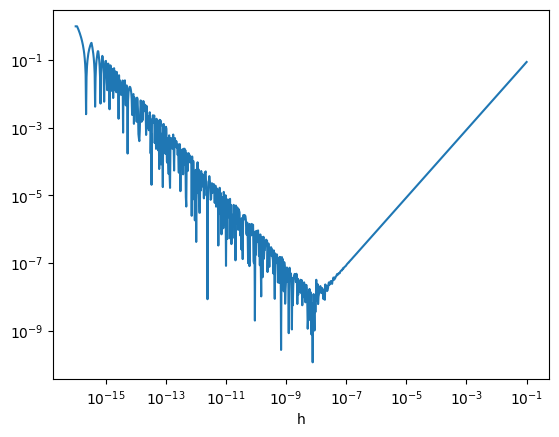

In [10]:
def f(x):
    """our function to numerically differentiate"""
    return np.sin(x)

def Dh(x, h):
    """a discrete approximation to the derivative at x"""
    return (f(x+h) - f(x))/h

def fprime(x):
    """the analytic derivative of f"""
    return np.cos(x)

# generate a set of h's from 1.e-16 to 0.1
hs = np.logspace(-16, -1, 1000)

# we'll look at the error at pi/3
x = np.pi/3.0

# compute the numerical difference for all h's
num_der = Dh(x, hs)

# get the analytic derivative
ans = fprime(x)

# compute the relative error
err = np.abs(num_der - ans)/ans

# plot the error vs h
fig, ax = plt.subplots()
ax.loglog(hs, err)
ax.set_xlabel("h")

Let's discuss the trends:

* Starting with the largest value of $h$, as 
  we make $h$ smaller, we see that the error decreases.
  This is following the expected behavior of the truncation error
  derived above.

* Once our $h$ becomes really small, roundoff error starts
  to dominate.  In effect, we are seeing that:

  $$(x_0 + h) - x_0 \ne h$$

  because of roundoff error.

* The minimum error here is around $\sqrt{\epsilon}$, where $\epsilon$ is
  machine epsilon.

We will explore a similar example in our homework.

**Note:** Because of roundoff error, we should never exactly compare two floating point numbers,
but instead ask that they agree within some tolerance, e.g., test equality as:

$$| x - y | < \epsilon$$

### Truncation Errors for Taylor Series

When representing a function, we can represent it as an infinite series. For instance, the function $e^x$ can be represented as
$$
e^x = \sum_{n=0}^{\infty} \frac{x^n}{n!}.
$$
Explicitly evaluating each term, this turns into

$$e^x = 1+x+\frac{x^2}{2!} + \frac{x^3}{3!} + \frac{x^4}{4!} + \dots$$

Since it takes the infinite sequence to approximate the function, if we only take a few items, we will have a truncation error. For example, if we only use the first 4 items to approximate $e^2$, which will be:

$$e^2 \approx 1+2+\frac{2^2}{2!} + \frac{2^3}{3!} = 6.3333$$, 

We see there is an error associated with it, since we truncate the rest of the terms in the Taylor series. Therefore the function $f(x)$ can be written as the Taylor series approximation, with an error truncation term $E_n$:

$$f(x) = f_n(x) + E_n(x)$$

with more terms we use, the approximation will be more close to the exact value. Let's use Python to see the above example. 

In [16]:
exp = 0
x = 2
for i in range(10):
    exp = exp + \
       ((x**i)/math.factorial(i))
    print(f'Using {i}-term, {exp}')
    
print(f'The true e^2 is: \n{np.exp(2)}')

Using 0-term, 1.0
Using 1-term, 3.0
Using 2-term, 5.0
Using 3-term, 6.333333333333333
Using 4-term, 7.0
Using 5-term, 7.266666666666667
Using 6-term, 7.355555555555555
Using 7-term, 7.3809523809523805
Using 8-term, 7.387301587301587
Using 9-term, 7.3887125220458545
The true e^2 is: 
7.38905609893065


## Other Errors

### Overflow

The finite amount of memory used for storing numbers means that there is a maximum and minimum possible number representable as well.

<img src="https://imgs.xkcd.com/comics/cant_sleep.png">

(credit: xkcd)

### NaN and Inf

These are defined "numbers" that represent floating point errors.  Consider:

Some NaNs: $\sqrt{-1}$, $0/0$, ...

Some infs: $1/0$

In [11]:
# the largest exponent we can store in double precision 
# floating point is 308.  What happens if we go beyond that?
a = 1.e308
print(a*10)

inf


# Exercises

### Exercise 1

What ~2-6 course projects seem interesting to you? List can be on project webpage, or come up with a project that is interesting on its own.

**Answer below**


### Exercise 2

Are you taking this course for honors credit? Just yes or no is fine

**Answer below**


### Exercise 3

What ~1-5 other people in the course might you be interested in "collaborating" with? Do you know if they are also taking this course for honors credit?

**Answer below**


### Exercise 4

Would you prefer to collaborate with group members doing a similar project? If you are ok with working with a collaborator working on a different topic than you, how different?

**Answer below**


### Exercise 5

The difference between 4.845 and 4.8 should be 0.055. But if you calculate it in Python, you will see the 4.9 - 4.845 is not equal to 0.055:

In [13]:
4.9 - 4.845 == 0.055

False

Print 4.9 - 4.845 in the cell below. How small is the roundoff error?

In [ ]:
## Answer here


### Exercise 6
 Adding $0.1 + 0.2 + 0.3$, we find in python this is not equal $0.6$, because of roundoff error:

In [14]:
0.1 + 0.2 + 0.3 == 0.6

False

Now, use the [round](https://www.w3schools.com/python/ref_func_round.asp) function to round the left and right sides. Use `round()` to return an expression where $0.1 + 0.2 + 0.3$ is equal to $0.6$.

In [ ]:
## Answer here


### Exercise 7

Below is an add and subtract function, that adds and subtracts $1/3$ from $1$ by a numbe of `iterations`:

In [ ]:
def add_and_subtract(iterations):
    result = 1
    
    for i in range(iterations):
        result += 1/3

    for i in range(iterations):
        result -= 1/3
    return result

How much does the result differ from $1$ if we carry out $10^2$ iterations? $10^3$? $10^4$?

In [ ]:
## Answer here


### Exercise 8

Write the Taylor series expansion for $e^{x^2}$ around $x=0$. Write a function `my_double_exp(x, n)`, which computes an approximation of $e^{x^2}$ using the first $n$ terms of the Taylor series expansion.

In [ ]:
## Answer here


### Exercise 9

The taylor series for $\cos x$ is
$$
\cos x = \sum_{n=0}^{\infty} \frac{(-1)^n x^{2n}}{(2n)!}.
$$
Use the 4th order Taylor series to approximate $\cos(0.2)$ and determine the truncation error bound.

In [ ]:
## Answer here
